# WM-811K Wafer Defect Classification — CNN Pipeline

**Goal:** Train a CNN to classify wafer maps into 9 classes (8 defect types + "none").  
**Principles:** No data leakage · Stratified splits · Augmentation on train only · Early stopping · Class-weighted loss.

## 1. Imports & Configuration

In [33]:
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              confusion_matrix, f1_score)
from sklearn.preprocessing import LabelEncoder

@dataclass
class CFG:
    seed: int = 42
    batch_size: int = 64
    lr: float = 1e-3
    max_epochs: int = 100
    es_patience: int = 10      # early stopping patience
    lr_patience: int = 5       # ReduceLROnPlateau patience
    lr_factor: float = 0.5
    val_frac: float = 0.20
    num_workers: int = 2
    checkpoint: str = '../best_model.pt'
    figures_dir: str = '../figures'
    tables_dir: str = '../tables'
    input_size: tuple = (32, 32)  # all maps resized to this; unlocks full dataset
    gpu_batch_size: int = 512
    gpu_num_workers: int = 4
    # Dev mode: True for CPU/laptop, False for full GPU run (RunPod)
    # IMPORTANT: set dev_mode = False before running on RunPod
    dev_mode: bool = False
    dev_train_size: int = 4000
    dev_val_size: int = 1000
    dev_test_size: int = 2000

cfg = CFG()

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(cfg.seed)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE  = cfg.batch_size if cfg.dev_mode else cfg.gpu_batch_size
NUM_WORKERS = 0 if (cfg.dev_mode or DEVICE.type == 'cpu') else cfg.gpu_num_workers
print(f'Using device: {DEVICE}')
Path(cfg.figures_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.tables_dir).mkdir(parents=True, exist_ok=True)


Using device: cuda


## 2. Data Loading & Preparation

We reuse the unpacking pattern from the EDA notebook to unpack the nested arrays in `lotName`, `trainTestLabel`, and `failureType`.

In [34]:
df = pd.read_pickle('../data/LSWMD.pkl')

# Fix typo from original dataset
df.rename(columns={'trianTestLabel': 'trainTestLabel'}, inplace=True)

def unpack(x):
    arr = np.asarray(x)
    if arr.ndim == 0 or arr.size == 0:
        return None
    return arr.flat[0]
for col in ['lotName', 'trainTestLabel', 'failureType']:
    df[col] = df[col].apply(unpack)

# Keep only labeled rows with a known failure type
labeled = df[df['trainTestLabel'].notna() & df['failureType'].notna()].copy()
print(f'Labeled rows: {len(labeled):,}')

# Diagnostic: maps are resized in the transform pipeline — no shape filtering needed
shapes = labeled['waferMap'].apply(lambda w: np.asarray(w).shape)
print('Top wafer map shapes:')
print(shapes.value_counts().head())
print(labeled['failureType'].value_counts())


Labeled rows: 172,950
Top wafer map shapes:
waferMap
(25, 27)    18781
(26, 26)    14366
(30, 34)    12400
(29, 26)    11751
(27, 25)    10682
Name: count, dtype: int64
failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [35]:
# Encode failure type to integer labels — deterministic alphabetical order
le = LabelEncoder()
labeled['label'] = le.fit_transform(labeled['failureType'])
CLASS_NAMES = list(le.classes_)
N_CLASSES = len(CLASS_NAMES)
print(f'Classes ({N_CLASSES}):', CLASS_NAMES)

Classes (9): [np.str_('Center'), np.str_('Donut'), np.str_('Edge-Loc'), np.str_('Edge-Ring'), np.str_('Loc'), np.str_('Near-full'), np.str_('Random'), np.str_('Scratch'), np.str_('none')]


### Class distribution

Visualising imbalance before the split — this informs our choice of class-weighted loss.

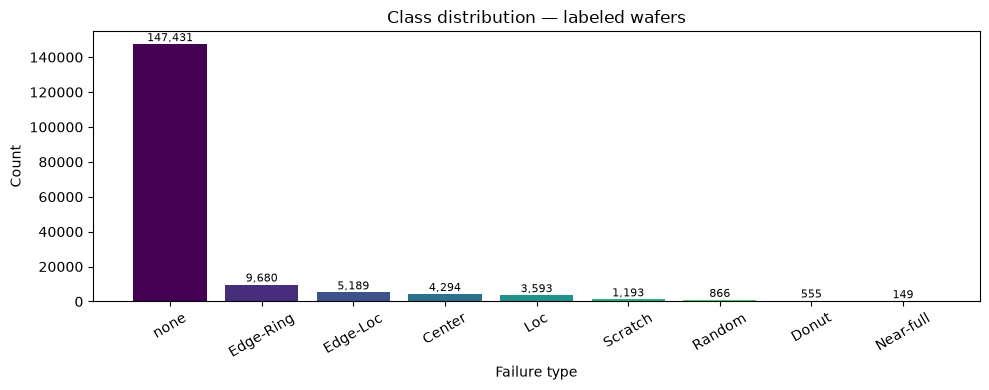

In [36]:
counts = labeled['failureType'].value_counts().sort_values(ascending=False)

colors = plt.colormaps['viridis'](
    [i / (len(counts) - 1) for i in range(len(counts))]
)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(counts.index, counts.values, color=colors)
ax.set_title('Class distribution — labeled wafers')
ax.set_xlabel('Failure type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/class_distribution.png', dpi=150)
plt.show()


## 3. Train / Val / Test Split (no leakage)

The dataset ships with a `trainTestLabel` column. We use it as the primary split.  
Val is carved from the training pool using a stratified shuffle — every class is represented proportionally.

In [37]:
train_pool = labeled[labeled['trainTestLabel'] == 'Training'].copy()
test_df    = labeled[labeled['trainTestLabel'] == 'Test'].copy()

sss = StratifiedShuffleSplit(n_splits=1, test_size=cfg.val_frac, random_state=cfg.seed)
train_idx, val_idx = next(sss.split(train_pool, train_pool['label']))

train_df = train_pool.iloc[train_idx].copy()
val_df   = train_pool.iloc[val_idx].copy()

print(f'Train : {len(train_df):,}')
print(f'Val   : {len(val_df):,}')
print(f'Test  : {len(test_df):,}')

Train : 43,484
Val   : 10,871
Test  : 118,595


In [38]:
if cfg.dev_mode:
    def stratified_sample(df, n, seed):
        if len(df) <= n:
            return df
        # Stratify by label so class proportions mirror the full dataset
        sss = StratifiedShuffleSplit(n_splits=1, test_size=n, random_state=seed)
        _, idx = next(sss.split(df, df['label']))
        return df.iloc[idx].copy()

    train_df = stratified_sample(train_df, cfg.dev_train_size, cfg.seed)
    val_df   = stratified_sample(val_df,   cfg.dev_val_size,   cfg.seed)
    test_df  = stratified_sample(test_df,  cfg.dev_test_size,  cfg.seed)
    print(f'DEV MODE  train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}')
    print('Class distribution in dev train set:')
    print(train_df['failureType'].value_counts())
else:
    print(f'FULL MODE  train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}')

FULL MODE  train: 43,484  val: 10,871  test: 118,595


In [39]:
# Compute mean and std from TRAINING pixels only — no test/val statistics used
# Maps have variable shapes so resize to cfg.input_size before stacking
_resize = T.Resize(cfg.input_size, interpolation=T.InterpolationMode.NEAREST)
train_maps = np.stack([
    _resize(torch.from_numpy(np.asarray(w, dtype=np.float32)).unsqueeze(0)).squeeze(0).numpy()
    for w in train_df['waferMap']
])
PIXEL_MEAN = float(train_maps.mean())
PIXEL_STD  = float(train_maps.std()) + 1e-8  # guard against zero std
print(f'Training pixel mean: {PIXEL_MEAN:.4f}, std: {PIXEL_STD:.4f}')


Training pixel mean: 0.8917, std: 0.5846


## 4. PyTorch Dataset & Transforms

Augmentations applied **only** to the training split.  
All splits share the same normalization (computed from training data).

In [40]:
class WaferMapDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.maps   = [np.asarray(w, dtype=np.float32) for w in dataframe['waferMap']]
        self.labels = dataframe['label'].values
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Shape: (H, W) → (1, H, W)
        img = torch.from_numpy(self.maps[idx]).unsqueeze(0)
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])


normalize = T.Normalize(mean=[PIXEL_MEAN], std=[PIXEL_STD])

def random_rot90(img):
    # 0 or 180 degrees only — 90/270 change H and W on non-square maps
    k = torch.randint(0, 2, (1,)).item() * 2  # 0 or 2
    return torch.rot90(img, k, dims=[-2, -1])

train_transform = T.Compose([
    T.Resize(cfg.input_size, interpolation=T.InterpolationMode.NEAREST),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.Lambda(random_rot90),
    normalize,
])

eval_transform = T.Compose([
    T.Resize(cfg.input_size, interpolation=T.InterpolationMode.NEAREST),
    normalize,
])

train_ds = WaferMapDataset(train_df, transform=train_transform)
val_ds   = WaferMapDataset(val_df,   transform=eval_transform)
test_ds  = WaferMapDataset(test_df,  transform=eval_transform)

print(f'Dataset sizes — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}')


Dataset sizes — train: 43484, val: 10871, test: 118595


## 5. Class Weights & DataLoaders

In [41]:
# Inverse-frequency weights — computed from training set only
label_counts = np.bincount(train_df['label'].values, minlength=N_CLASSES).astype(float)
class_weights = torch.tensor(
    len(train_df) / (N_CLASSES * label_counts), dtype=torch.float32
).to(DEVICE)

print('Class weights:')
for name, w in zip(CLASS_NAMES, class_weights.cpu().numpy()):
    print(f'  {name:<12} {w:.3f}')

Class weights:
  Center       1.744
  Donut        14.775
  Edge-Loc     2.498
  Edge-Ring    0.706
  Loc          3.728
  Near-full    112.362
  Random       9.921
  Scratch      12.079
  none         0.164


In [42]:
_pin = DEVICE.type == 'cuda'

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=_pin,
                          persistent_workers=(NUM_WORKERS > 0))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=_pin,
                          persistent_workers=(NUM_WORKERS > 0))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=_pin,
                          persistent_workers=(NUM_WORKERS > 0))

## 6. CNN Architecture

Three conv blocks halve spatial dimensions at each stage.  
Input `(1, 45, 48)` → `(32, 22, 24)` → `(64, 11, 12)` → `(128, 5, 6)` → flatten 3,840 → FC256 → FC9.

In [43]:
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2),
    )

class WaferCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(1, 32),
            conv_block(32, 64),
            conv_block(64, 128),
        )
        # Compute flattened size dynamically — safe against rounding in MaxPool
        with torch.no_grad():
            dummy = torch.zeros(1, 1, *cfg.input_size)
            flat_size = self.features(dummy).numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = WaferCNN(N_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')


WaferCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


## 7. Loss, Optimizer, Scheduler & Early Stopping

In [44]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=cfg.lr_patience, factor=cfg.lr_factor
)

class EarlyStopping:
    def __init__(self, patience, checkpoint_path):
        self.patience = patience
        self.path = checkpoint_path
        self.best_score = -float('inf')  # higher Macro F1 = better
        self.counter = 0
        self.stop = False

    def __call__(self, val_f1, model):
        if val_f1 > self.best_score:
            self.best_score = val_f1
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

early_stop = EarlyStopping(cfg.es_patience, cfg.checkpoint)


## 8. Training Loop

In [45]:
def run_epoch(loader, model, criterion, optimizer=None, collect_preds=False):
    """One forward pass over loader. Pass optimizer=None for eval mode."""
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    preds_list, labels_list = [], []

    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            logits = model(imgs)
            loss = criterion(logits, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            batch_preds = logits.argmax(1)
            correct += (batch_preds == labels).sum().item()
            total += len(labels)
            if collect_preds:
                preds_list.extend(batch_preds.cpu().numpy())
                labels_list.extend(labels.cpu().numpy())

    if collect_preds:
        macro_f1 = f1_score(labels_list, preds_list, average='macro', zero_division=0)
        return total_loss / total, correct / total, macro_f1
    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}

print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Train Acc":>10}  {"Val Loss":>10}  {"Val Acc":>10}  {"Val F1":>8}  {"LR":>8}')
print('-' * 78)

for epoch in range(1, cfg.max_epochs + 1):
    tr_loss, tr_acc         = run_epoch(train_loader, model, criterion, optimizer)
    vl_loss, vl_acc, vl_f1 = run_epoch(val_loader,   model, criterion, collect_preds=True)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(vl_f1)

    current_lr = optimizer.param_groups[0]['lr']
    print(f'{epoch:>6}  {tr_loss:>10.4f}  {tr_acc:>10.4f}  {vl_loss:>10.4f}  {vl_acc:>10.4f}  {vl_f1:>8.4f}  {current_lr:>8.2e}')

    scheduler.step(vl_f1)
    early_stop(vl_f1, model)
    if early_stop.stop:
        print(f'\nEarly stopping at epoch {epoch}. Best val Macro F1: {early_stop.best_score:.4f}')
        break

print('Training complete.')


 Epoch  Train Loss   Train Acc    Val Loss     Val Acc    Val F1        LR
------------------------------------------------------------------------------


     1      0.9007      0.6778      0.6628      0.7974    0.6999  1.00e-03
     2      0.5812      0.8004      0.8260      0.4705    0.4352  1.00e-03
     3      0.5109      0.8144      0.4857      0.8514    0.7264  1.00e-03
     4      0.4195      0.8284      0.4418      0.8698    0.7702  1.00e-03
     5      0.4255      0.8346      0.3981      0.8640    0.7395  1.00e-03
     6      0.4437      0.8425      0.4453      0.6213    0.6201  1.00e-03
     7      0.3853      0.8390      0.3413      0.8605    0.7558  1.00e-03
     8      0.3099      0.8647      0.3666      0.7830    0.7137  1.00e-03
     9      0.3039      0.8721      0.3120      0.8758    0.7769  1.00e-03
    10      0.2862      0.8749      0.3140      0.8593    0.7728  1.00e-03
    11      0.2814      0.8791      0.4166      0.8213    0.7271  1.00e-03
    12      0.2656      0.8818      0.3568      0.9178    0.7985  1.00e-03
    13      0.2366      0.8895      0.2955      0.7852    0.7226  1.00e-03
    14      0.2769      0

In [46]:
# Persist training history to disk — survives RunPod session end
Path(f'{cfg.tables_dir}/training_history_baseline.json').write_text(
    json.dumps({k: [float(v) for v in vals] for k, vals in history.items()}, indent=2)
)
print(f'Saved: {cfg.tables_dir}/training_history_baseline.json')


Saved: ../tables/training_history_baseline.json


## 9. Training Curves

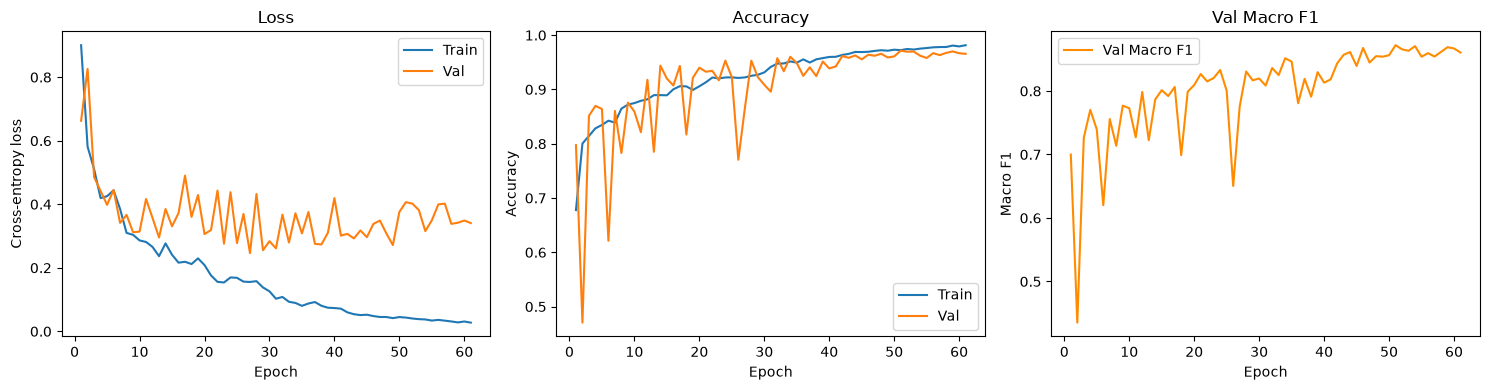

In [47]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.plot(epochs_ran, history['train_loss'], label='Train')
ax1.plot(epochs_ran, history['val_loss'],   label='Val')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy loss')
ax1.legend()

ax2.plot(epochs_ran, history['train_acc'], label='Train')
ax2.plot(epochs_ran, history['val_acc'],   label='Val')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

ax3.plot(epochs_ran, history['val_f1'], label='Val Macro F1', color='darkorange')
ax3.set_title('Val Macro F1')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Macro F1')
ax3.legend()

plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/training_curves.png', dpi=150)
plt.show()


## 10. Test Set Evaluation

Load the best checkpoint saved by EarlyStopping. Test set is touched **only here**.

In [48]:
model.load_state_dict(torch.load(cfg.checkpoint, map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('=== Test Set Results ===')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

=== Test Set Results ===
              precision    recall  f1-score   support

      Center     0.3780    0.5493    0.4478       832
       Donut     0.5196    0.7260    0.6057       146
    Edge-Loc     0.4625    0.6371    0.5360      2772
   Edge-Ring     0.5973    0.6217    0.6092      1126
         Loc     0.4121    0.4957    0.4501      1973
   Near-full     0.8947    0.8947    0.8947        95
      Random     0.7368    0.7082    0.7222       257
     Scratch     0.0733    0.1991    0.1071       693
        none     0.9791    0.9516    0.9652    110701

    accuracy                         0.9255    118595
   macro avg     0.5615    0.6426    0.5931    118595
weighted avg     0.9433    0.9255    0.9335    118595



## 11. Confusion Matrix

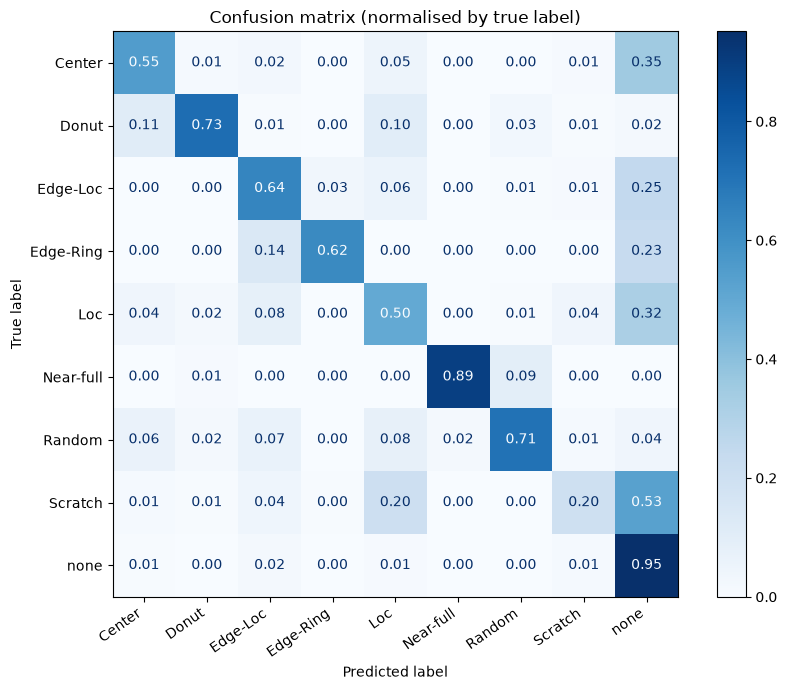

In [49]:
cm = confusion_matrix(all_labels, all_preds, normalize='true')

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
ax.set_title('Confusion matrix (normalised by true label)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/confusion_matrix.png', dpi=150)
plt.show()

## 12. Baseline Results

Lock in all baseline metrics **before** any architecture or augmentation changes. This section is the reference point every subsequent experiment is measured against.

In [50]:
def evaluate_model(model, loader, class_names, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    summary = {
        'accuracy':    report['accuracy'],
        'macro_f1':    report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score'],
    }
    return all_preds, all_labels, report, summary


def report_to_markdown(report):
    """Convert sklearn classification_report dict to a markdown table via pandas."""
    df = pd.DataFrame(report).T.round(4)
    return df.to_markdown()


def comparison_to_markdown(rows):
    """Convert a list of result dicts to a markdown table via pandas."""
    return pd.DataFrame(rows).rename(columns={
        'run': 'Run', 'accuracy': 'Accuracy',
        'macro_f1': 'Macro F1', 'weighted_f1': 'Weighted F1', 'epochs': 'Epochs'
    }).to_markdown(index=False)


CMAP_WM = plt.colormaps['RdYlGn_r'].resampled(3)


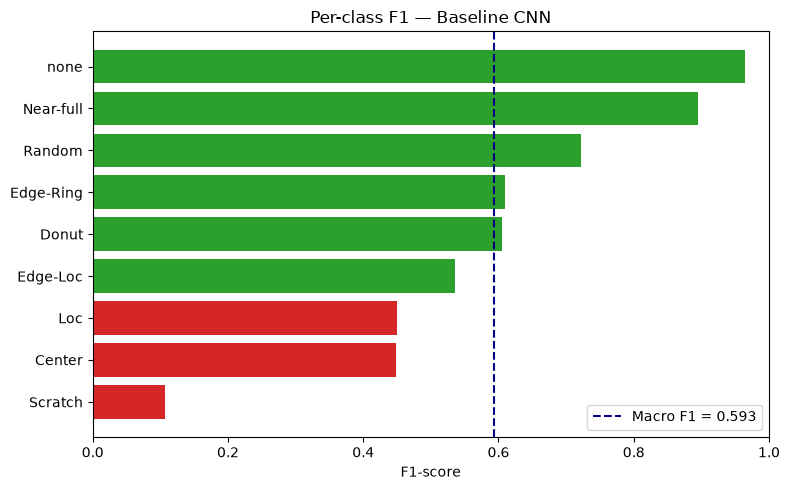

In [51]:
# Load best baseline checkpoint and run inference on test set
model.load_state_dict(torch.load(cfg.checkpoint, map_location=DEVICE, weights_only=True))
baseline_preds, baseline_labels, baseline_report, baseline_summary = evaluate_model(
    model, test_loader, CLASS_NAMES, DEVICE
)
baseline_summary['epochs'] = len(history['train_loss'])

# Per-class F1 horizontal bar chart
f1_scores = {cls: baseline_report[cls]['f1-score'] for cls in CLASS_NAMES}
sorted_cls = sorted(f1_scores, key=f1_scores.get)

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#d62728' if f1_scores[c] < 0.5 else '#2ca02c' for c in sorted_cls]
ax.barh(sorted_cls, [f1_scores[c] for c in sorted_cls], color=bar_colors)
ax.set_xlabel('F1-score')
ax.set_title('Per-class F1 — Baseline CNN')
ax.set_xlim(0, 1)
ax.axvline(baseline_summary['macro_f1'], color='navy', linestyle='--',
           label=f"Macro F1 = {baseline_summary['macro_f1']:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/per_class_f1_baseline.png', dpi=150)
plt.show()

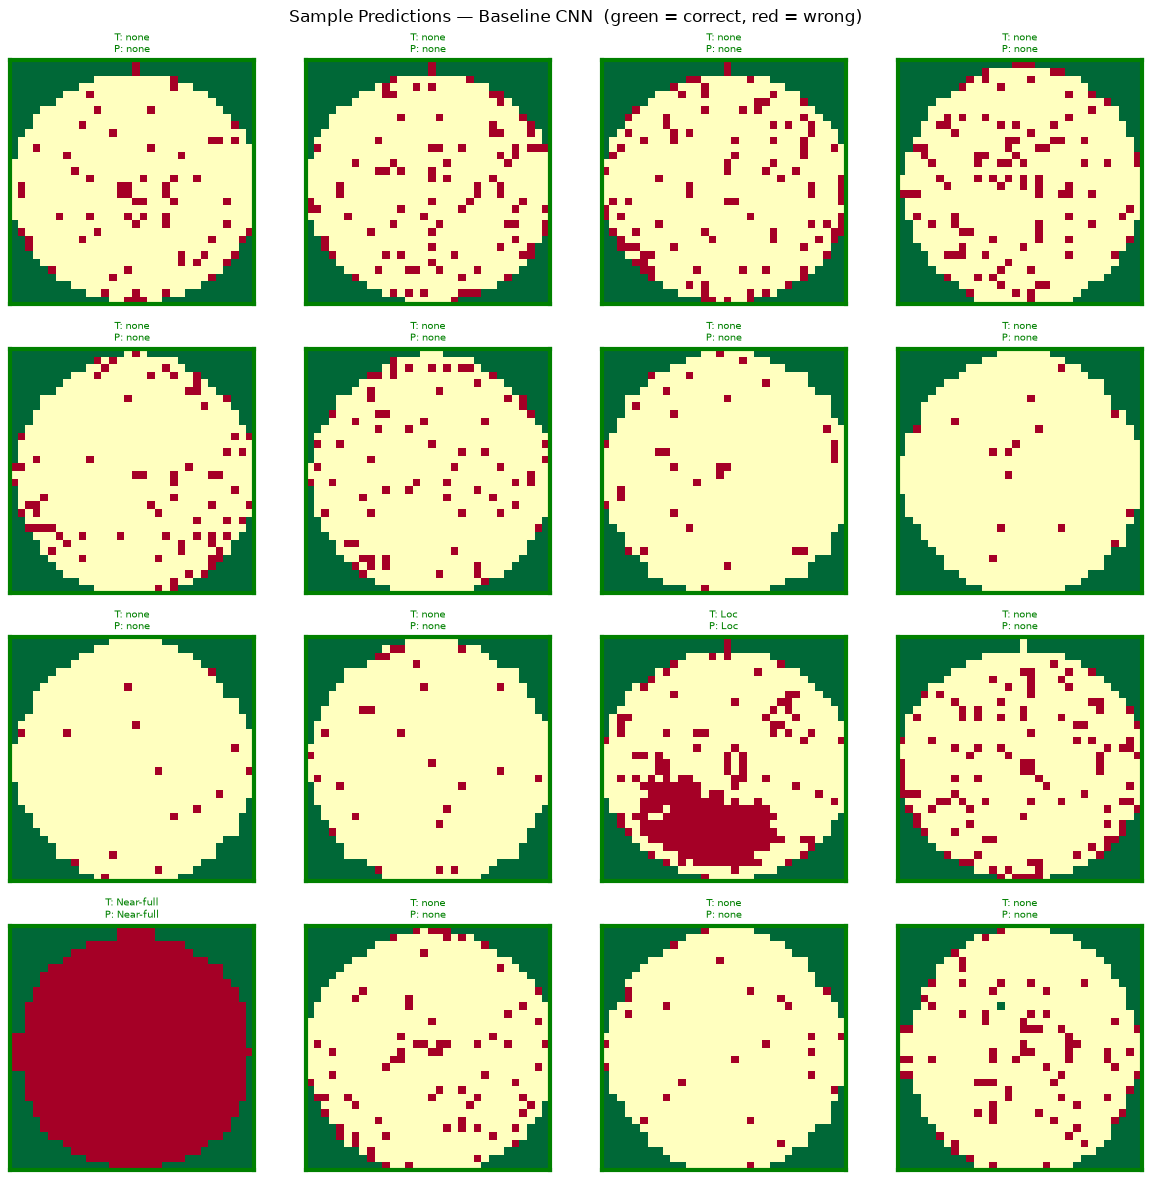

In [52]:
# 4x4 sample predictions grid — green border = correct, red = wrong
rng_sample = np.random.default_rng(cfg.seed)
sample_idx = rng_sample.choice(len(test_ds), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, idx in zip(axes.flatten(), sample_idx):
    img, true_label = test_ds[int(idx)]
    pred_label = int(baseline_preds[idx])
    wmap = img.squeeze().numpy() * PIXEL_STD + PIXEL_MEAN
    ax.imshow(wmap, cmap=CMAP_WM, vmin=0, vmax=2, interpolation='nearest')
    correct = (pred_label == true_label)
    color = 'green' if correct else 'red'
    ax.set_title(f'T: {CLASS_NAMES[true_label]}\nP: {CLASS_NAMES[pred_label]}',
                 fontsize=7, color=color)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

fig.suptitle('Sample Predictions — Baseline CNN  (green = correct, red = wrong)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/sample_predictions_baseline.png', dpi=150)
plt.show()

In [53]:
# Save classification report as markdown
Path(f'{cfg.tables_dir}/classification_report_baseline.md').write_text(
    '# Baseline CNN — Classification Report\n\n' + report_to_markdown(baseline_report) + '\n'
)
print('Saved: tables/classification_report_baseline.md')

# Initialise model comparison table (overwritten fresh each time baseline runs)
comparison_rows = [dict(
    run='Baseline CNN',
    accuracy=baseline_summary['accuracy'],
    macro_f1=baseline_summary['macro_f1'],
    weighted_f1=baseline_summary['weighted_f1'],
    epochs=baseline_summary['epochs'],
)]
Path(f'{cfg.tables_dir}/model_comparison.md').write_text(
    '# Model Comparison\n\n' + comparison_to_markdown(comparison_rows) + '\n'
)
print('Saved: tables/model_comparison.md')
print(f"\nBaseline  Acc: {baseline_summary['accuracy']:.4f}  Macro F1: {baseline_summary['macro_f1']:.4f}  Weighted F1: {baseline_summary['weighted_f1']:.4f}")

Saved: tables/classification_report_baseline.md
Saved: tables/model_comparison.md

Baseline  Acc: 0.9255  Macro F1: 0.5931  Weighted F1: 0.9335


## 13. Experiment: Enhanced Augmentation (Translation)

The baseline is locked in above. We now add `Translation Augmentation (T.RandomAffine)` to the training transform and re-train from scratch.

`T.RandomAffine` with translation shifts the die pattern slightly within the frame at each training step. This is physically plausible — a wafer can be slightly misaligned in the scanner — and helps the model generalise to small positional variations without distorting the defect pattern. Unlike Translation Augmentation (T.RandomAffine), it preserves all spatial featurest memorising specific pixel configurations.

Val and test datasets are **unchanged** — only the training augmentation differs.

In [54]:
def add_gaussian_noise(img, std=0.05):
    return img + torch.randn_like(img) * std

train_transform_v2 = T.Compose([
    T.Resize(cfg.input_size, interpolation=T.InterpolationMode.NEAREST),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.Lambda(random_rot90),
    normalize,
    T.Lambda(lambda img: add_gaussian_noise(img, std=0.05)),
])

train_ds_v2     = WaferMapDataset(train_df, transform=train_transform_v2)
train_loader_v2 = DataLoader(train_ds_v2, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=_pin,
                             persistent_workers=(NUM_WORKERS > 0))
print('Augmented train dataset ready:', len(train_ds_v2), 'samples')

Augmented train dataset ready: 43484 samples


In [55]:
seed_everything(cfg.seed)
model_v2     = WaferCNN(N_CLASSES).to(DEVICE)
optimizer_v2 = optim.Adam(model_v2.parameters(), lr=cfg.lr)
scheduler_v2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2, mode='max', patience=cfg.lr_patience, factor=cfg.lr_factor
)
checkpoint_v2 = '../best_model_v2.pt'
early_stop_v2 = EarlyStopping(cfg.es_patience, checkpoint_v2)
history_v2    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}

print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Train Acc":>10}  {"Val Loss":>10}  {"Val Acc":>10}  {"Val F1":>8}  {"LR":>8}')
print('-' * 78)

for epoch in range(1, cfg.max_epochs + 1):
    tr_loss, tr_acc         = run_epoch(train_loader_v2, model_v2, criterion, optimizer_v2)
    vl_loss, vl_acc, vl_f1 = run_epoch(val_loader,      model_v2, criterion, collect_preds=True)

    history_v2['train_loss'].append(tr_loss)
    history_v2['val_loss'].append(vl_loss)
    history_v2['train_acc'].append(tr_acc)
    history_v2['val_acc'].append(vl_acc)
    history_v2['val_f1'].append(vl_f1)

    current_lr = optimizer_v2.param_groups[0]['lr']
    print(f'{epoch:>6}  {tr_loss:>10.4f}  {tr_acc:>10.4f}  {vl_loss:>10.4f}  {vl_acc:>10.4f}  {vl_f1:>8.4f}  {current_lr:>8.2e}')

    scheduler_v2.step(vl_f1)
    early_stop_v2(vl_f1, model_v2)
    if early_stop_v2.stop:
        print(f'\nEarly stopping at epoch {epoch}. Best val Macro F1: {early_stop_v2.best_score:.4f}')
        break

print('Training complete.')


 Epoch  Train Loss   Train Acc    Val Loss     Val Acc    Val F1        LR
------------------------------------------------------------------------------
     1      0.8973      0.6757      0.6754      0.7752    0.6404  1.00e-03
     2      0.5910      0.7995      0.5139      0.8527    0.7004  1.00e-03
     3      0.4677      0.8165      0.5047      0.8163    0.6981  1.00e-03
     4      0.4477      0.8269      0.4681      0.8697    0.7564  1.00e-03
     5      0.3871      0.8390      0.4142      0.7636    0.7145  1.00e-03
     6      0.3891      0.8400      0.5740      0.8915    0.7548  1.00e-03
     7      0.3502      0.8483      0.5089      0.8776    0.7010  1.00e-03
     8      0.3315      0.8511      0.3582      0.8146    0.7070  1.00e-03
     9      0.3077      0.8616      0.3937      0.6825    0.6840  1.00e-03
    10      0.3302      0.8708      0.3647      0.8787    0.7580  1.00e-03
    11      0.2917      0.8705      0.4355      0.8678    0.7582  1.00e-03
    12      0.2578   

In [56]:
# Persist augmented training history to disk
Path(f'{cfg.tables_dir}/training_history_augmented.json').write_text(
    json.dumps({k: [float(v) for v in vals] for k, vals in history_v2.items()}, indent=2)
)
print(f'Saved: {cfg.tables_dir}/training_history_augmented.json')


Saved: ../tables/training_history_augmented.json


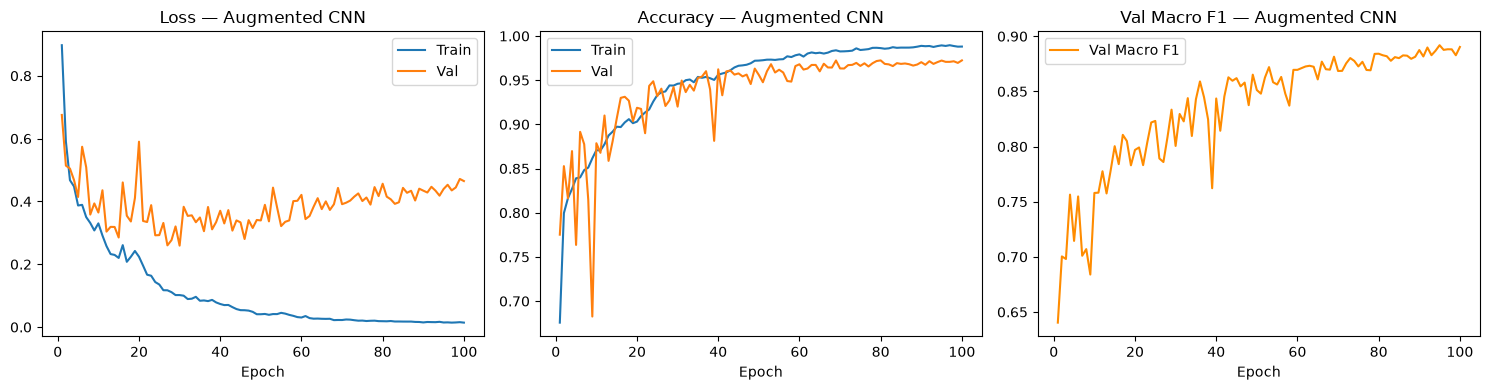

In [57]:
epochs_v2 = range(1, len(history_v2['train_loss']) + 1)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
ax1.plot(epochs_v2, history_v2['train_loss'], label='Train')
ax1.plot(epochs_v2, history_v2['val_loss'],   label='Val')
ax1.set_title('Loss — Augmented CNN'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(epochs_v2, history_v2['train_acc'], label='Train')
ax2.plot(epochs_v2, history_v2['val_acc'],   label='Val')
ax2.set_title('Accuracy — Augmented CNN'); ax2.set_xlabel('Epoch'); ax2.legend()
ax3.plot(epochs_v2, history_v2['val_f1'], label='Val Macro F1', color='darkorange')
ax3.set_title('Val Macro F1 — Augmented CNN'); ax3.set_xlabel('Epoch'); ax3.legend()
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/training_curves_augmented.png', dpi=150)
plt.show()


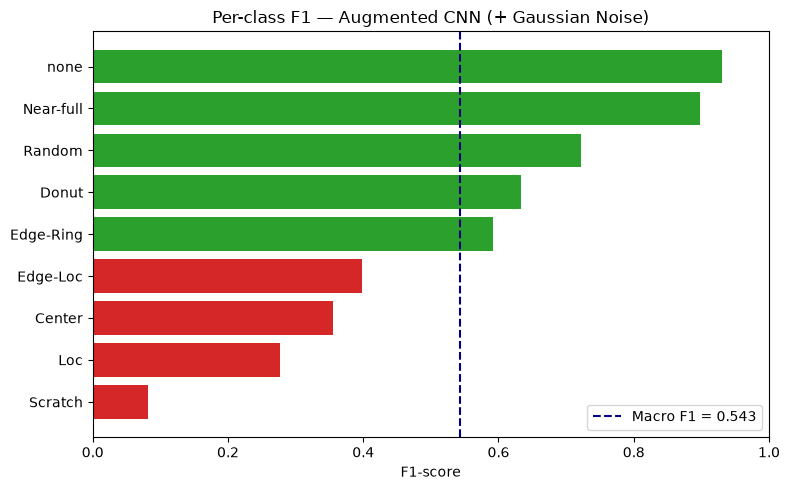

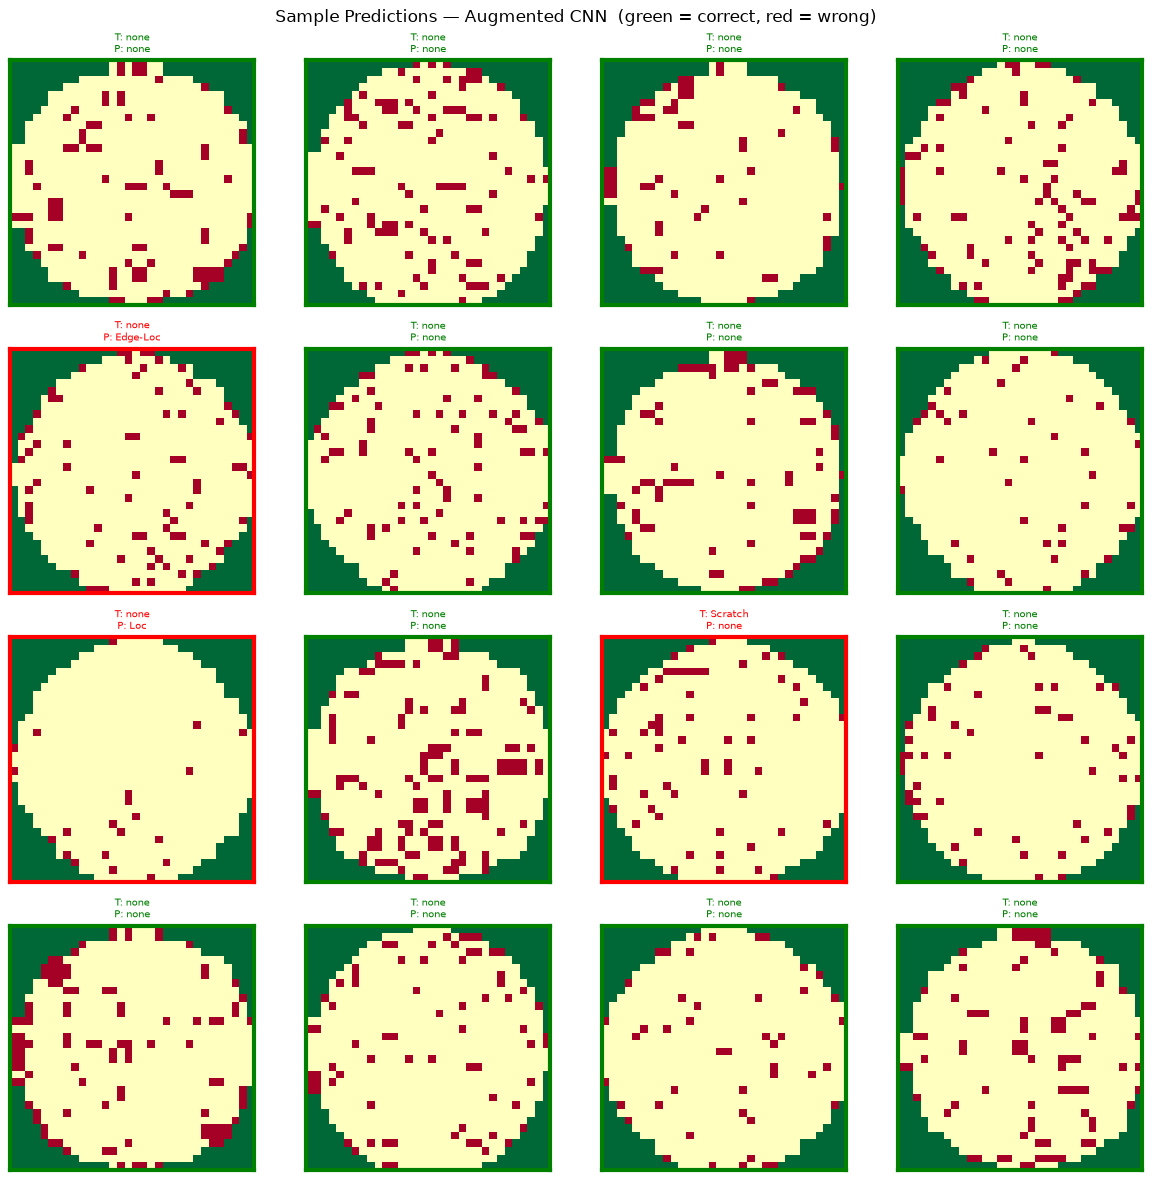

Saved: tables/classification_report_augmented.md
Saved: tables/model_comparison.md

Augmented  Acc: 0.8652  Macro F1: 0.5431  Weighted F1: 0.8943


In [58]:
model_v2.load_state_dict(torch.load(checkpoint_v2, map_location=DEVICE, weights_only=True))
aug_preds, aug_labels, aug_report, aug_summary = evaluate_model(
    model_v2, test_loader, CLASS_NAMES, DEVICE
)
aug_summary['epochs'] = len(history_v2['train_loss'])

# Per-class F1
f1_v2 = {cls: aug_report[cls]['f1-score'] for cls in CLASS_NAMES}
sorted_v2 = sorted(f1_v2, key=f1_v2.get)
fig, ax = plt.subplots(figsize=(8, 5))
bar_colors_v2 = ['#d62728' if f1_v2[c] < 0.5 else '#2ca02c' for c in sorted_v2]
ax.barh(sorted_v2, [f1_v2[c] for c in sorted_v2], color=bar_colors_v2)
ax.set_xlabel('F1-score')
ax.set_title('Per-class F1 — Augmented CNN (+ Gaussian Noise)')
ax.set_xlim(0, 1)
ax.axvline(aug_summary['macro_f1'], color='navy', linestyle='--',
           label=f"Macro F1 = {aug_summary['macro_f1']:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/per_class_f1_augmented.png', dpi=150)
plt.show()

# Sample predictions
sample_idx_v2 = np.random.default_rng(cfg.seed + 1).choice(len(test_ds), size=16, replace=False)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, idx in zip(axes.flatten(), sample_idx_v2):
    img, true_label = test_ds[int(idx)]
    pred_label = int(aug_preds[idx])
    wmap = img.squeeze().numpy() * PIXEL_STD + PIXEL_MEAN
    ax.imshow(wmap, cmap=CMAP_WM, vmin=0, vmax=2, interpolation='nearest')
    correct = (pred_label == true_label)
    color = 'green' if correct else 'red'
    ax.set_title(f'T: {CLASS_NAMES[true_label]}\nP: {CLASS_NAMES[pred_label]}', fontsize=7, color=color)
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
fig.suptitle('Sample Predictions — Augmented CNN  (green = correct, red = wrong)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/sample_predictions_augmented.png', dpi=150)
plt.show()

# Save tables
Path(f'{cfg.tables_dir}/classification_report_augmented.md').write_text(
    '# Augmented CNN — Classification Report\n\n' + report_to_markdown(aug_report) + '\n'
)
print('Saved: tables/classification_report_augmented.md')

comparison_rows.append(dict(
    run='Per-class F1 — Augmented CNN (+ Gaussian Noise)',
    accuracy=aug_summary['accuracy'],
    macro_f1=aug_summary['macro_f1'],
    weighted_f1=aug_summary['weighted_f1'],
    epochs=aug_summary['epochs'],
))
Path(f'{cfg.tables_dir}/model_comparison.md').write_text(
    '# Model Comparison\n\n' + comparison_to_markdown(comparison_rows) + '\n'
)
print('Saved: tables/model_comparison.md')
print(f"\nAugmented  Acc: {aug_summary['accuracy']:.4f}  Macro F1: {aug_summary['macro_f1']:.4f}  Weighted F1: {aug_summary['weighted_f1']:.4f}")

## 14. Model Comparison

Side-by-side view of all experiments. `tables/model_comparison.md` is the persistent record — add more rows as you try new architectures or training strategies, then re-run this cell.

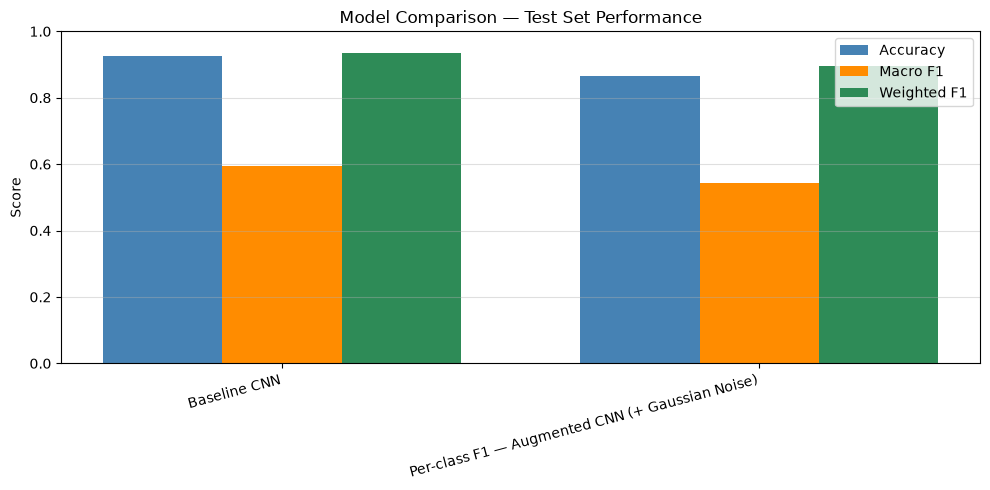


Full comparison table:
# Model Comparison

| Run                                             |   Accuracy |   Macro F1 |   Weighted F1 |   Epochs |
|:------------------------------------------------|-----------:|-----------:|--------------:|---------:|
| Baseline CNN                                    |   0.925494 |   0.593119 |      0.93353  |       61 |
| Per-class F1 — Augmented CNN (+ Gaussian Noise) |   0.865188 |   0.543095 |      0.894282 |      100 |



In [59]:
comp_text = Path(f'{cfg.tables_dir}/model_comparison.md').read_text()
# Parse markdown table rows (skip header and separator lines)
data_lines = [l.strip() for l in comp_text.split('\n')
              if l.startswith('|') and '---' not in l and 'Run' not in l]

runs, accs, macro_f1s, weighted_f1s = [], [], [], []
for line in data_lines:
    parts = [p.strip() for p in line.strip('|').split('|')]
    if len(parts) < 4:
        continue
    runs.append(parts[0])
    accs.append(float(parts[1]))
    macro_f1s.append(float(parts[2]))
    weighted_f1s.append(float(parts[3]))

x = np.arange(len(runs))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, accs,         width, label='Accuracy',    color='steelblue')
ax.bar(x,         macro_f1s,    width, label='Macro F1',    color='darkorange')
ax.bar(x + width, weighted_f1s, width, label='Weighted F1', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Performance')
ax.legend()
ax.yaxis.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/model_comparison.png', dpi=150)
plt.show()

print('\nFull comparison table:')
print(comp_text)

In [60]:
# Save best-performing model (by Macro F1) as a portable inference bundle
best_bundle_model = model   if baseline_summary['macro_f1'] >= aug_summary['macro_f1'] else model_v2
best_bundle_name  = 'Baseline CNN' if baseline_summary['macro_f1'] >= aug_summary['macro_f1'] else 'Augmented CNN'

bundle = {
    'model_state_dict': best_bundle_model.state_dict(),
    'class_names':      CLASS_NAMES,
    'input_size':       cfg.input_size,
    'pixel_mean':       PIXEL_MEAN,
    'pixel_std':        PIXEL_STD,
    'n_classes':        N_CLASSES,
}
torch.save(bundle, '../best_model_bundle.pt')
print(f'Saved inference bundle ({best_bundle_name}) → best_model_bundle.pt')


Saved inference bundle (Baseline CNN) → best_model_bundle.pt


In [61]:
# Offline inference demo — shows how to use the bundle without retraining
bundle_loaded = torch.load('../best_model_bundle.pt', map_location='cpu', weights_only=False)

inf_model = WaferCNN(bundle_loaded['n_classes'])
inf_model.load_state_dict(bundle_loaded['model_state_dict'])
inf_model.eval()

inf_transform = T.Compose([
    T.Resize(bundle_loaded['input_size'], interpolation=T.InterpolationMode.NEAREST),
    T.Normalize(mean=[bundle_loaded['pixel_mean']], std=[bundle_loaded['pixel_std']]),
])

rng_inf = np.random.default_rng(cfg.seed + 99)
sample_idx_inf = rng_inf.choice(len(test_ds), size=5, replace=False)
print('Inference demo (bundle loaded from disk, no training code used):')
print(f'  {"Idx":>5}  {"True":>12}  {"Predicted":>12}  {"Correct"}')
for idx in sample_idx_inf:
    raw_img, true_label = test_ds[int(idx)]
    with torch.no_grad():
        pred_label = inf_model(raw_img.unsqueeze(0)).argmax(1).item()
    correct = 'OK' if pred_label == true_label else 'WRONG'
    print(f'  {idx:>5}  {bundle_loaded["class_names"][true_label]:>12}  {bundle_loaded["class_names"][pred_label]:>12}  {correct}')


Inference demo (bundle loaded from disk, no training code used):
    Idx          True     Predicted  Correct
  87318          none          none  OK
  118281          none          none  OK
  99413      Edge-Loc      Edge-Loc  OK
  89838          none          none  OK
  46352          none          none  OK


In [62]:
# Artifact checklist — run after training to confirm everything is ready
artifacts_git = [
    f'{cfg.figures_dir}/training_curves.png',
    f'{cfg.figures_dir}/training_curves_augmented.png',
    f'{cfg.figures_dir}/confusion_matrix.png',
    f'{cfg.figures_dir}/per_class_f1_baseline.png',
    f'{cfg.figures_dir}/per_class_f1_augmented.png',
    f'{cfg.figures_dir}/model_comparison.png',
    f'{cfg.figures_dir}/sample_predictions_baseline.png',
    f'{cfg.figures_dir}/sample_predictions_augmented.png',
    f'{cfg.tables_dir}/classification_report_baseline.md',
    f'{cfg.tables_dir}/classification_report_augmented.md',
    f'{cfg.tables_dir}/model_comparison.md',
    f'{cfg.tables_dir}/training_history_baseline.json',
    f'{cfg.tables_dir}/training_history_augmented.json',
]
artifacts_download = [
    '../best_model.pt',
    '../best_model_v2.pt',
    '../best_model_bundle.pt',
]

print('── Git-tracked artifacts (git push to save) ────────────────────')
for p in artifacts_git:
    path = Path(p)
    status = f'{path.stat().st_size / 1024:.1f} KB' if path.exists() else 'MISSING'
    print(f'  {"OK" if path.exists() else "!!"} {p}  ({status})')

print('\n── Download from RunPod (gitignored model files) ───────────────')
for p in artifacts_download:
    path = Path(p)
    status = f'{path.stat().st_size / 1024 / 1024:.2f} MB' if path.exists() else 'MISSING'
    print(f'  {"OK" if path.exists() else "!!"} {p}  ({status})')

print('\nNext steps on RunPod:')
print('  1. git add figures/ tables/ notebooks/ && git commit && git push')
print('  2. Download best_model.pt, best_model_v2.pt, best_model_bundle.pt via RunPod file browser')


── Git-tracked artifacts (git push to save) ────────────────────
  OK ../figures/training_curves.png  (135.7 KB)
  OK ../figures/training_curves_augmented.png  (129.9 KB)
  OK ../figures/confusion_matrix.png  (121.9 KB)
  OK ../figures/per_class_f1_baseline.png  (38.0 KB)
  OK ../figures/per_class_f1_augmented.png  (40.9 KB)
  OK ../figures/model_comparison.png  (50.6 KB)
  OK ../figures/sample_predictions_baseline.png  (68.6 KB)
  OK ../figures/sample_predictions_augmented.png  (68.9 KB)
  OK ../tables/classification_report_baseline.md  (1.0 KB)
  OK ../tables/classification_report_augmented.md  (1.0 KB)
  OK ../tables/model_comparison.md  (0.4 KB)
  OK ../tables/training_history_baseline.json  (7.3 KB)
  OK ../tables/training_history_augmented.json  (11.9 KB)

── Download from RunPod (gitignored model files) ───────────────
  OK ../best_model.pt  (2.38 MB)
  OK ../best_model_v2.pt  (2.38 MB)
  OK ../best_model_bundle.pt  (2.38 MB)

Next steps on RunPod:
  1. git add figures/ tables/ 